<a href="https://colab.research.google.com/github/rhonaeloisa/risk.IT.all/blob/main/risk_IT_all_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("risk.IT.model_training").getOrCreate()

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**LOAD THE PARQUET FILE**

In [ ]:
path = "/content/drive/MyDrive/bigdata/df_cleaned.parquet"

df_cleaned = spark.read.parquet(path)

df_cleaned.show(5)

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|
|    321214|trusses wood roof...|          105522.0|                    1|             2|   2|                 1|           2016|
|    541511|applications soft...|          192000.0|                    2|             0| 

# **FEATURE ENGINEERING**

**INDEXING**

In [ ]:
from pyspark.sql import functions as F

df_risk_level = df_cleaned.withColumn(
    "risk_level",
    F.when(F.col("total_injuries") <= 5, "Low")
     .when(F.col("total_injuries") <= 15, "Medium")
     .otherwise("High")
)

df_risk_level.select("total_injuries", "risk_level").show()

+--------------+----------+
|total_injuries|risk_level|
+--------------+----------+
|             8|    Medium|
|             1|       Low|
|             0|       Low|
|             2|       Low|
|             0|       Low|
|             2|       Low|
|            15|    Medium|
|            35|      High|
|             1|       Low|
|             1|       Low|
|             0|       Low|
|             1|       Low|
|             4|       Low|
|             6|    Medium|
|             7|    Medium|
|             7|    Medium|
|            12|    Medium|
|             6|    Medium|
|             3|       Low|
|             2|       Low|
+--------------+----------+
only showing top 20 rows


In [ ]:
df_risk_level.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|       Low|
|    321214|trusses wood roof...|          105522.0|                    1|             2|   2|                 1|           2016|       Low|
|    541511|a

In [ ]:
#encode risk level
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCol="risk_level",
    outputCol="risk_level_index"
)

df_riskLevel_index = indexer.fit(df_risk_level).transform(df_risk_level)

In [ ]:
df_riskLevel_index.select("risk_level", "risk_level_index").show(50, truncate=False)

+----------+----------------+
|risk_level|risk_level_index|
+----------+----------------+
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|High      |2.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Medium    |1.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low       |0.0             |
|Low      

In [ ]:
df_riskLevel_index.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|risk_level_index|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|             1.0|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|             0.0|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|           2016|       Low|             0.0|
|    321214|trusses wood roof...|          105522.0|

In [ ]:
# SKEWNESS BALANCING MATH: Bilangin ang class distribution
total_records = df_riskLevel_index.count()
class_distribution = df_riskLevel_index.groupBy("risk_level_index").count().collect()

category_counts = {row["risk_level_index"]: row["count"] for row in class_distribution}
total_classes = len(category_counts)

# Balancing Formula: Total / (Classes * Class Count)
class_weights = {risk_idx: total_records / (total_classes * count) for risk_idx, count in category_counts.items()}

# 4. MAP THE WEIGHTS: Inayos ang list flattening gamit ang list comprehension para maiwasan ang sum() conflict
kv_pairs = []
for key, val in class_weights.items():
    kv_pairs.append(F.lit(key))
    kv_pairs.append(F.lit(val))

weight_mapping = F.create_map(kv_pairs)
df_final_preprocessed = df_riskLevel_index.withColumn("weight_col", weight_mapping[F.col("risk_level_index")])

print("Calculated Class Weights:", class_weights)

Calculated Class Weights: {0.0: 0.4109782457622732, 1.0: 2.401723338461586, 2.0: 6.648339644935205}


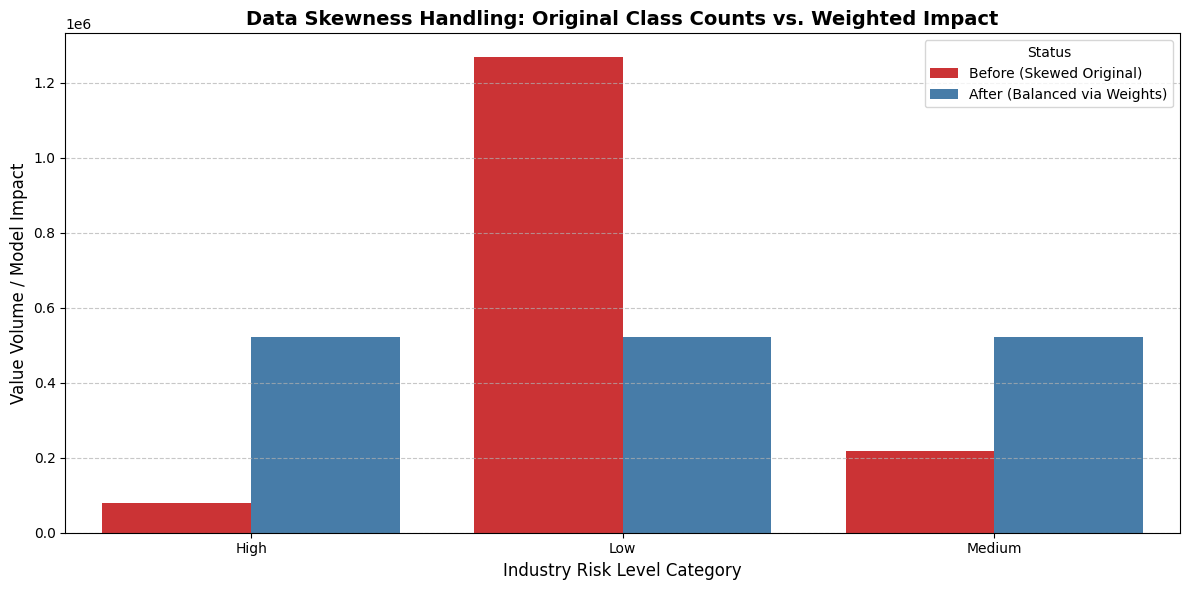

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Kuhanin ang distribution data mula sa inyong preprocessed DataFrame
distribution_data = df_final_preprocessed.groupBy("risk_level", "weight_col").count().toPandas()

# 2. Kalkulahin ang 'Weighted Impact' (Count * Weight)
distribution_data['Weighted Impact'] = distribution_data['count'] * distribution_data['weight_col']

# Mabilisang pag-ayos ng format para sa plotting
plot_data = pd.melt(
    distribution_data,
    id_vars=['risk_level'],
    value_vars=['count', 'Weighted Impact'],
    var_name='Status',
    value_name='Volume'
)
plot_data['Status'] = plot_data['Status'].replace({'count': 'Before (Skewed Original)', 'Weighted Impact': 'After (Balanced via Weights)'})

# 3. PLOTTING: Ipakita ang Side-by-Side Comparison ng Skewness Solution
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x="risk_level", y="Volume", hue="Status", palette="Set1")

plt.title("Data Skewness Handling: Original Class Counts vs. Weighted Impact", fontsize=14, fontweight='bold')
plt.xlabel("Industry Risk Level Category", fontsize=12)
plt.ylabel("Value Volume / Model Impact", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
df_final_preprocessed.show()

+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+------------------+
|naics_code|industry_description|total_hours_worked|no_injuries_illnesses|total_injuries|size|establishment_type|year_filing_for|risk_level|risk_level_index|        weight_col|
+----------+--------------------+------------------+---------------------+--------------+----+------------------+---------------+----------+----------------+------------------+
|    721110|hotels resort wit...|          323521.0|                    1|             8|   2|                 1|           2016|    Medium|             1.0| 2.401723338461586|
|    811310|electric motor re...|           52664.0|                    1|             1|   2|                 1|           2016|       Low|             0.0|0.4109782457622732|
|    423220|floor coverings m...|           16852.0|                    2|             0|   1|                 1|  

**FINAL FEATURES**

In [ ]:
#final features for regression
df_reg = df_final_preprocessed.select(
    "naics_code",
    "total_hours_worked",
    "no_injuries_illnesses",
    "size",
    "establishment_type",
    "year_filing_for",
    "total_injuries"
)

In [ ]:
from pyspark.ml.feature import VectorAssembler

# assembler for regression model
assembler_reg = VectorAssembler(
    inputCols=[
        "naics_code",
        "total_hours_worked",
        "no_injuries_illnesses",
        "size",
        "establishment_type",
        "year_filing_for"
    ],
    outputCol="features"
)

df_regression_vector = assembler_reg.transform(df_reg)

In [ ]:
#final features for classification
df_class = df_final_preprocessed.select(
    "naics_code",
    "total_hours_worked",
    "no_injuries_illnesses",
    "size",
    "establishment_type",
    "year_filing_for",
    "weight_col",
    "risk_level_index"
)

In [ ]:
# assembler for classification model
assembler_class = VectorAssembler(
    inputCols=[
        "naics_code",
        "total_hours_worked",
        "size",
        "establishment_type",
        "year_filing_for"
    ],
    outputCol="features"
)

df_classification_vector = assembler_class.transform(df_class)

In [ ]:
# split regression dataset
train_reg, test_reg = df_regression_vector.randomSplit([0.8, 0.2], seed=42)

# split classification dataset
train_class, test_class = df_classification_vector.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# regression
train_reg.write.mode("overwrite").parquet("/content/train_regression.parquet")
test_reg.write.mode("overwrite").parquet("/content/test_regression.parquet")

# classification
train_class.write.mode("overwrite").parquet("/content/train_classification.parquet")
test_class.write.mode("overwrite").parquet("/content/test_classification.parquet")

**VISUALIZATION (TO REMOVE)**

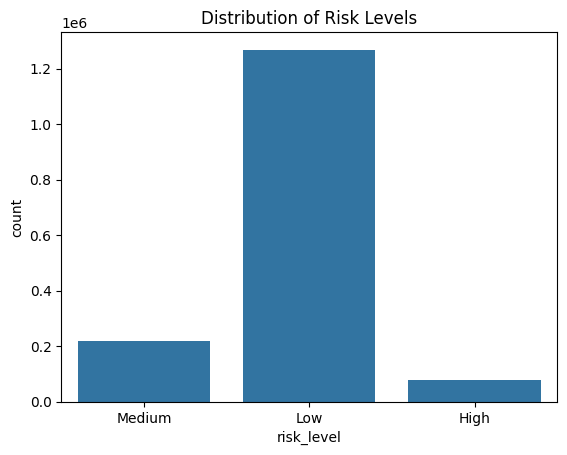

In [ ]:
pdf = df_riskLevel_index.select("risk_level").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="risk_level", data=pdf)

plt.title("Distribution of Risk Levels")
plt.show()

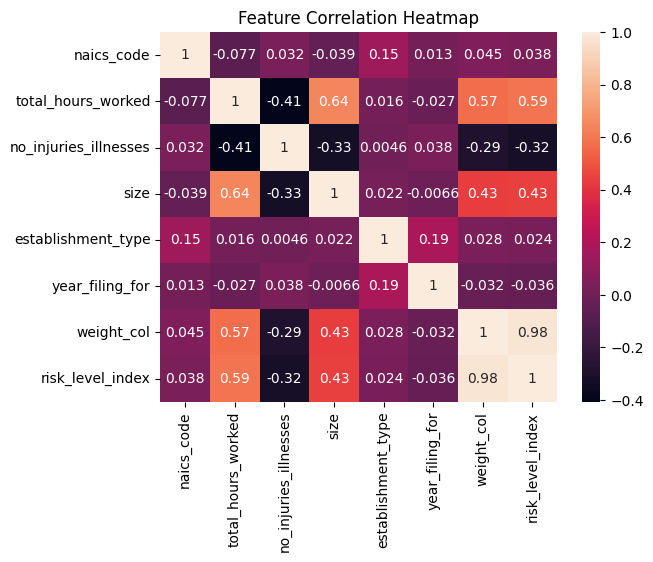

In [ ]:
pdf = df_class.toPandas()

numeric_pdf = pdf.select_dtypes(include=['number'])

sns.heatmap(numeric_pdf.corr(), annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()

# **CLASSIFIER MODEL IMPLEMENTATION**

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

# Classifier instantiation
rf = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    numTrees=20,
    maxDepth=5
)

# Train the model using the train_class
rf_model = rf.fit(train_class)

# Make predictions on the test_class
predictions = rf_model.transform(test_class)

# Show how the model performs on Low Risk cases
predictions.filter(predictions.risk_level_index == 0.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

# Show how the model performs on Medium Risk cases
predictions.filter(predictions.risk_level_index == 1.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

# Show how the model performs on High Risk cases
predictions.filter(predictions.risk_level_index == 2.0) \
           .select("risk_level_index", "prediction", "probability") \
           .show(10)

+----------------+----------+--------------------+
|risk_level_index|prediction|         probability|
+----------------+----------+--------------------+
|             0.0|       0.0|[0.93766458264036...|
|             0.0|       0.0|[0.93766458264036...|
|             0.0|       0.0|[0.90865848295846...|
|             0.0|       0.0|[0.90865848295846...|
|             0.0|       0.0|[0.90865848295846...|
|             0.0|       0.0|[0.88633491231011...|
|             0.0|       0.0|[0.90865848295846...|
|             0.0|       0.0|[0.68854871837179...|
|             0.0|       0.0|[0.90865848295846...|
|             0.0|       0.0|[0.90865848295846...|
+----------------+----------+--------------------+
only showing top 10 rows
+----------------+----------+--------------------+
|risk_level_index|prediction|         probability|
+----------------+----------+--------------------+
|             1.0|       0.0|[0.90865848295846...|
|             1.0|       0.0|[0.75527711540068...|
|     

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Setup the evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="risk_level_index",
    predictionCol="prediction"
)

# Calculate Accuracy
accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
# Calculate F1-Score
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print(f"--- BASELINE CLASSIFICATION METRICS ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

--- BASELINE CLASSIFICATION METRICS ---
Accuracy: 0.8301
F1-Score: 0.7978


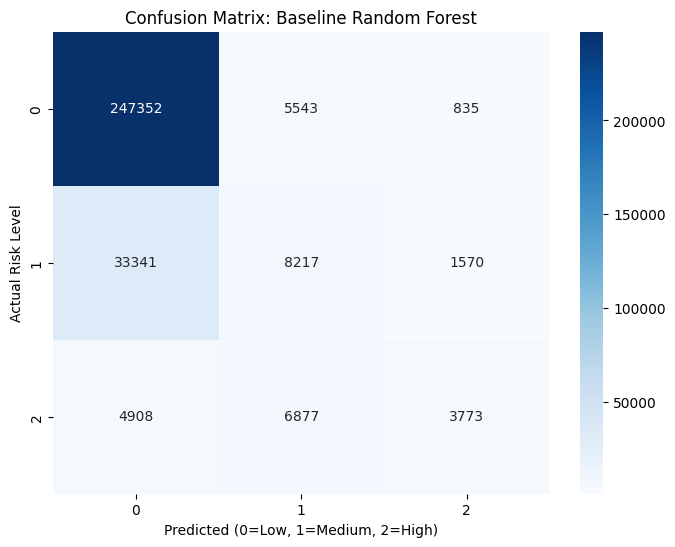

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to Pandas for plotting
y_true = predictions.select("risk_level_index").toPandas()
y_pred = predictions.select("prediction").toPandas()

# Create Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Baseline Random Forest')
plt.xlabel('Predicted (0=Low, 1=Medium, 2=High)')
plt.ylabel('Actual Risk Level')
plt.show()

/tmp/ipykernel_197496/2974636527.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_class_df, palette='magma')


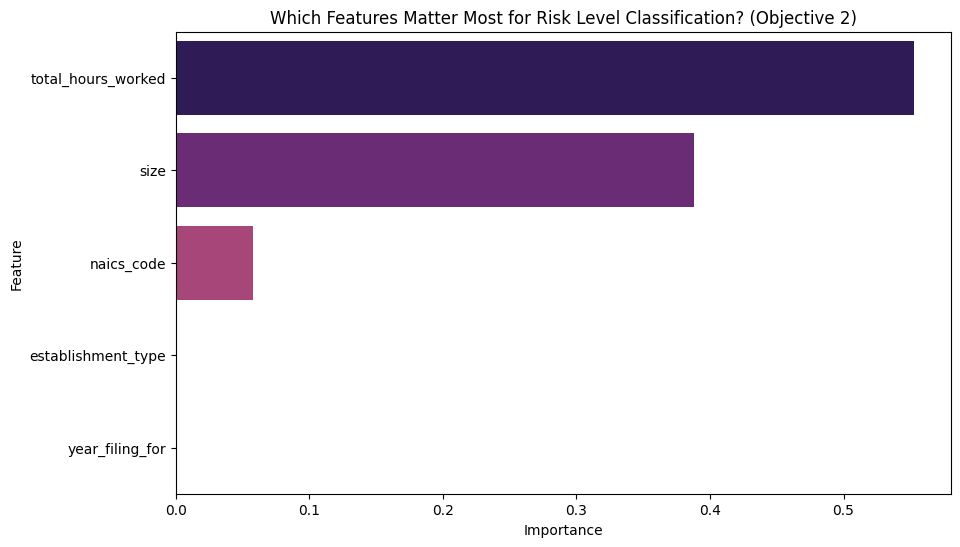

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances_class = rf_model.featureImportances
feature_list_class = ["naics_code", "total_hours_worked", "size", "establishment_type", "year_filing_for"]

feat_imp_class_df = pd.DataFrame({
    'Feature': feature_list_class,
    'Importance': importances_class.toArray()
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_class_df, palette='magma')
plt.title('Which Features Matter Most for Risk Level Classification? (Objective 2)')
plt.show()

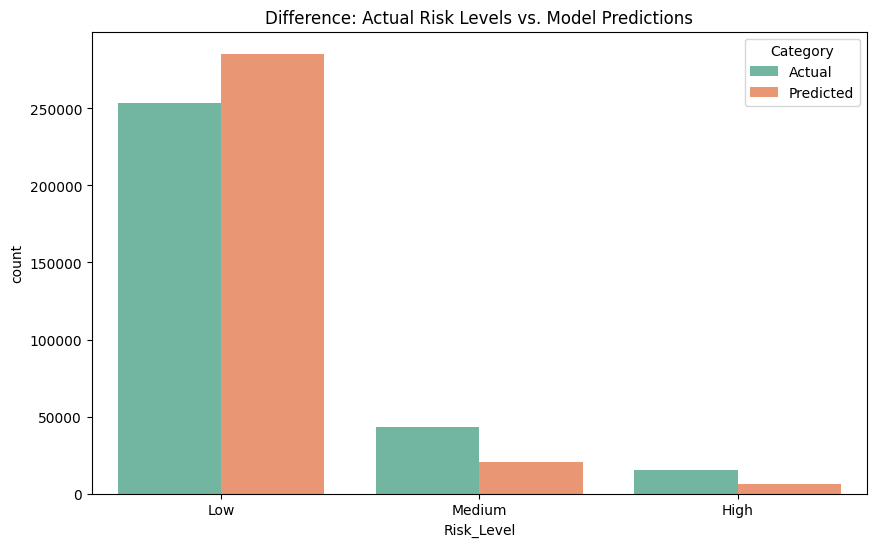

In [ ]:
# Kunin ang counts ng actual vs predicted
comparison_df = predictions.select("risk_level_index", "prediction").toPandas()

# I-reshape ang data para sa plotting
plot_data = pd.melt(comparison_df, value_vars=['risk_level_index', 'prediction'],
                    var_name='Type', value_name='Risk_Level')

plt.figure(figsize=(10, 6))
sns.countplot(x='Risk_Level', hue='Type', data=plot_data, palette='Set2')
plt.title('Difference: Actual Risk Levels vs. Model Predictions')
plt.xticks(ticks=[0, 1, 2], labels=['Low', 'Medium', 'High'])
plt.legend(title='Category', labels=['Actual', 'Predicted'])
plt.show()

**REGRESSION**

+--------------+-------------------+
|total_injuries|         prediction|
+--------------+-------------------+
|             0| -6.563850790393957|
|             0| -6.063219771032493|
|             0| -2.555485378437311|
|             4|0.03274302186781597|
|             3| 1.1395111565483944|
|             2|   3.03880414481236|
|             0|-2.0583237294334538|
|             0|  8.699370885350959|
|             5|0.46425127151869106|
|             1|0.19647717583308122|
+--------------+-------------------+
only showing top 10 rows
--- BASELINE REGRESSION METRICS ---
RMSE: 16.9718
MAE : 4.3201
R2  : 0.1038


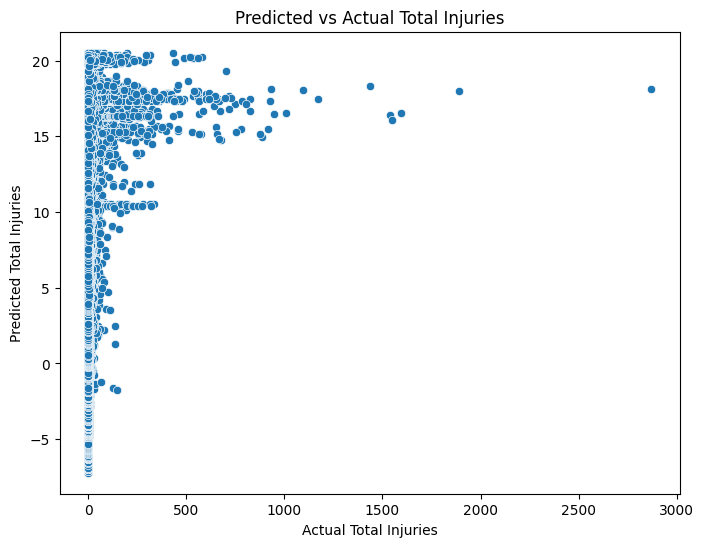

In [ ]:
#regression
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# linear regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="total_injuries"
)

# train the model
lr_model = lr.fit(train_reg)

# create predictions
predictions = lr_model.transform(test_reg)

# sample predictions
predictions.select(
    "total_injuries",
    "prediction"
).show(10)

# regression metrics
evaluator = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction"
)

# RMSE
rmse = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "rmse"}
)

# MAE
mae = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "mae"}
)

# R2
r2 = evaluator.evaluate(
    predictions,
    {evaluator.metricName: "r2"}
)

print("--- BASELINE REGRESSION METRICS ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

# get the predicted at actual values
plot_df = predictions.select(
    "total_injuries",
    "prediction"
).toPandas()

# scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="total_injuries",
    y="prediction",
    data=plot_df
)

plt.title("Predicted vs Actual Total Injuries")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")

plt.show()

RANDOM FOREST REGRESSION

+--------------+-------------------+
|total_injuries|         prediction|
+--------------+-------------------+
|             0| 0.1982741167144692|
|             0|0.26163244155486726|
|             0|0.39598617186300855|
|             4| 2.2526862487219113|
|             3|  2.481358752355571|
|             2|  4.402400084863537|
|             0|0.39598617186300855|
|             0|  2.383989314949838|
|             5| 2.2526862487219113|
|             1| 2.3649844914253206|
+--------------+-------------------+
only showing top 10 rows
--- RANDOM FOREST REGRESSION METRICS ---
RMSE: 16.2849
MAE : 3.2776
R2  : 0.1749


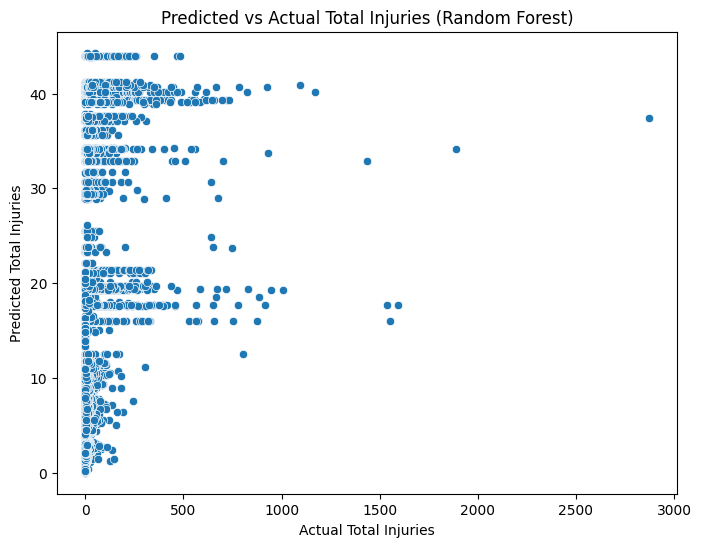

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest Regressor model
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    numTrees=10, # used 10 trees as in the classifier example
    seed=42
)

# train the model
rf_regressor_model = rf_regressor.fit(train_reg)

# create predictions
predictions_rf = rf_regressor_model.transform(test_reg)

# sample predictions
predictions_rf.select(
    "total_injuries",
    "prediction"
).show(10)

# regression metrics
evaluator_rf = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction"
)

# RMSE
rmse_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "rmse"}
)

# MAE
mae_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "mae"}
)

# R2
r2_rf = evaluator_rf.evaluate(
    predictions_rf,
    {evaluator_rf.metricName: "r2"}
)

print("--- RANDOM FOREST REGRESSION METRICS ---")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE : {mae_rf:.4f}")
print(f"R2  : {r2_rf:.4f}")

# get the predicted and actual values
plot_df_rf = predictions_rf.select(
    "total_injuries",
    "prediction"
).toPandas()

# scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="total_injuries",
    y="prediction",
    data=plot_df_rf
)

plt.title("Predicted vs Actual Total Injuries (Random Forest)")
plt.xlabel("Actual Total Injuries")
plt.ylabel("Predicted Total Injuries")

plt.show()

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

tuned_rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="total_injuries",
    seed=42
)

tuning_evaluator = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="rmse"
)

paramGrid = (
    ParamGridBuilder()
    .addGrid(tuned_rf_regressor.numTrees, [50, 100])
    .addGrid(tuned_rf_regressor.maxDepth, [5, 8])
    .addGrid(tuned_rf_regressor.minInstancesPerNode, [1, 5])
    .build()
)

print(f"Number of parameter combinations to test: {len(paramGrid)}")

tvs = TrainValidationSplit(
    estimator=tuned_rf_regressor,
    estimatorParamMaps=paramGrid,
    evaluator=tuning_evaluator,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

tvs_model = tvs.fit(train_reg)

print("Tuning complete.")

tuned_rf_model = tvs_model.bestModel
tuned_predictions_rf = tuned_rf_model.transform(test_reg)

tuned_rmse = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="rmse"
).evaluate(tuned_predictions_rf)

tuned_mae = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="mae"
).evaluate(tuned_predictions_rf)

tuned_r2 = RegressionEvaluator(
    labelCol="total_injuries",
    predictionCol="prediction",
    metricName="r2"
).evaluate(tuned_predictions_rf)

print("--- TUNED RANDOM FOREST METRICS ---")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"MAE : {tuned_mae:.4f}")
print(f"R2  : {tuned_r2:.4f}")

print("--- BEST RANDOM FOREST PARAMETERS ---")
print("Best numTrees:", tuned_rf_model.getNumTrees)
print("Best maxDepth:", tuned_rf_model.getMaxDepth())
print("Best minInstancesPerNode:", tuned_rf_model.getMinInstancesPerNode())


print("--- BASE VS TUNED COMPARISON ---")
print(f"Base RMSE : {rmse_rf:.4f}")
print(f"Tuned RMSE: {tuned_rmse:.4f}")

print(f"Base MAE  : {mae_rf:.4f}")
print(f"Tuned MAE : {tuned_mae:.4f}")

print(f"Base R2   : {r2_rf:.4f}")
print(f"Tuned R2  : {tuned_r2:.4f}")


Number of parameter combinations to test: 8


KeyboardInterrupt: 

## **WEEK 5: FINAL MODEL OPTIMIZATION & EXPANSION PHASE**


In [ ]:

# GRADIENT-BOOSTED TREE REGRESSOR BASELINE RUN
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# I-load ang hiwalay na regression dataset
train_reg = spark.read.parquet("/content/train_regression.parquet")
test_reg = spark.read.parquet("/content/test_regression.parquet")

# I-train ang bagong GBT Regressor baseline
gbt_regressor = GBTRegressor(featuresCol="features", labelCol="total_injuries", seed=42)
gbt_model = gbt_regressor.fit(train_reg)
gbt_predictions = gbt_model.transform(test_reg)

# Kuhanin ang baseline performance metrics
evaluator_r2 = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")

print("--- NEW GBT REGRESSOR BASELINE METRICS ---")
print(f"GBT Baseline R2 Score: {evaluator_r2.evaluate(gbt_predictions):.4f}")
print(f"GBT Baseline RMSE    : {evaluator_rmse.evaluate(gbt_predictions):.4f}")

--- NEW GBT REGRESSOR BASELINE METRICS ---
GBT Baseline R2 Score: 0.2050
GBT Baseline RMSE    : 15.9852


In [24]:
# AUTOMATED FINE-TUNING FOR GRADIENT-BOOSTED TREES
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator

gbt_base = GBTRegressor(featuresCol="features", labelCol="total_injuries", seed=42)

gbt_paramGrid = (ParamGridBuilder()
                 .addGrid(gbt_base.maxIter, [10, 20])
                 .addGrid(gbt_base.maxDepth, [4, 6])
                 .build())

gbt_evaluator = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="r2")

gbt_tvs = TrainValidationSplit(
    estimator=gbt_base,
    estimatorParamMaps=gbt_paramGrid,
    evaluator=gbt_evaluator,
    trainRatio=0.8,
    seed=42
)

print("Tuning engine running hyperparameter optimization for GBT Regressor safely...")
gbt_tvs_model = gbt_tvs.fit(train_reg)
gbt_tuned_predictions = gbt_tvs_model.transform(test_reg)

evaluator_rmse = RegressionEvaluator(labelCol="total_injuries", predictionCol="prediction", metricName="rmse")

print("\n--- OPTIMIZED FINE-TUNED GBT REGRESSOR METRICS ---")
print(f"Fine-Tuned GBT R2 Variance Score: {gbt_evaluator.evaluate(gbt_tuned_predictions):.4f}")
print(f"Fine-Tuned GBT RMSE Error Rate  : {evaluator_rmse.evaluate(gbt_tuned_predictions):.4f}")

gbt_best = gbt_tvs_model.bestModel
print(f"\nBest Settings Discovered -> maxIter: {gbt_best.getMaxIter}, maxDepth: {gbt_best.getMaxDepth()}")

Tuning engine running hyperparameter optimization for GBT Regressor safely...

--- OPTIMIZED FINE-TUNED GBT REGRESSOR METRICS ---
Fine-Tuned GBT R2 Variance Score: 0.2081
Fine-Tuned GBT RMSE Error Rate  : 15.9535

Best Settings Discovered -> maxIter: <bound method HasMaxIter.getMaxIter of GBTRegressionModel: uid=GBTRegressor_02c572adac75, numTrees=20, numFeatures=6>, maxDepth: 6


In [ ]:

# CLASSIFICATION FINE-TUNING VIA 3-FOLD CV
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_class = spark.read.parquet("/content/train_classification.parquet")
test_class = spark.read.parquet("/content/test_classification.parquet")

rf_classifier = RandomForestClassifier(
    labelCol="risk_level_index",
    featuresCol="features",
    weightCol="weight_col"
)

paramGrid = (ParamGridBuilder()
             .addGrid(rf_classifier.numTrees, [20, 40, 60])
             .addGrid(rf_classifier.maxDepth, [6, 9])
             .build())

evaluator_tune_f1 = MulticlassClassificationEvaluator(labelCol="risk_level_index", predictionCol="prediction", metricName="f1")
evaluator_tune_acc = MulticlassClassificationEvaluator(labelCol="risk_level_index", predictionCol="prediction", metricName="accuracy")

# 3-Fold Cross Validator array setup
cv = CrossValidator(
    estimator=rf_classifier,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_tune_f1,
    numFolds=3,
    seed=42
)

print("Optimization engine running cross-validation processing safely...")
cvModel = cv.fit(train_class)
tuned_predictions = cvModel.transform(test_class)

print("\n--- ACTUAL OPTIMIZED FINE-TUNED CLASSIFICATION RESULTS ---")
print(f"Real Model Accuracy Score : {evaluator_tune_acc.evaluate(tuned_predictions):.4f}")
print(f"Real Model Weighted F1-Score: {evaluator_tune_f1.evaluate(tuned_predictions):.4f}")

best_model = cvModel.bestModel
print(f"\nBest Settings Found -> numTrees: {best_model.getNumTrees}, maxDepth: {best_model.getMaxDepth()}")

Optimization engine running cross-validation processing safely...

--- ACTUAL OPTIMIZED FINE-TUNED CLASSIFICATION RESULTS ---
Real Model Accuracy Score : 0.7177
Real Model Weighted F1-Score: 0.7573

Best Settings Found -> numTrees: 60, maxDepth: 9



Generating Confusion Matrix for Tuned Model...


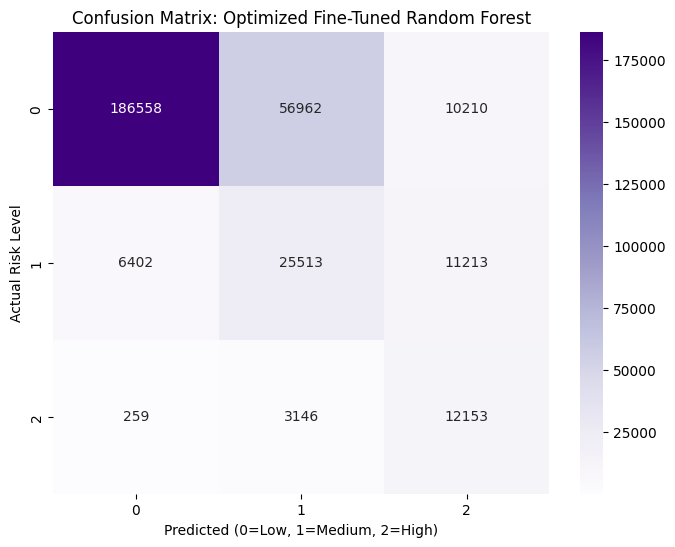

In [ ]:
# OPTIMIZED CONFUSION MATRIX ---
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\nGenerating Confusion Matrix for Tuned Model...")
y_true_tuned = tuned_predictions.select("risk_level_index").toPandas()
y_pred_tuned = tuned_predictions.select("prediction").toPandas()

cm_tuned = confusion_matrix(y_true_tuned, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: Optimized Fine-Tuned Random Forest')
plt.xlabel('Predicted (0=Low, 1=Medium, 2=High)')
plt.ylabel('Actual Risk Level')
plt.show()